In [ ]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

: 

In [74]:
ruta_imagen = "img/izq5.jpeg"

# Se lee la imagen como BGR por default
imagen = cv2.imread("img/izq5.jpeg")
# Se lee la imagen en RGB
imagen_RGB = cv2.imread("img/izq5.jpeg", cv2.IMREAD_COLOR_RGB)
# Se lee la imagen en BGR
imagen_BGR = cv2.imread("img/izq5.jpeg", cv2.IMREAD_COLOR_BGR)
# Se lee la imagen en escala de grises
imagen_GRAYSCALE = cv2.imread("img/izq5.jpeg", cv2.IMREAD_GRAYSCALE)
# Se convierte a HSV desde RGB
imagen_HSV = cv2.cvtColor(imagen_RGB, cv2.COLOR_RGB2HSV)

In [75]:
# El formato en el que debe estar la imagen debe ser en BGR
# De otra forma se mostrará mal
cv2.imshow("Imagen a color en BGR", imagen_BGR)
cv2.waitKey(0)

-1

In [76]:
print(f'Estructura de la imagen RGB {imagen_RGB.shape}')
print(f'Estructura de la imagen HSV {imagen_HSV.shape}')
print(f'Estructura de la imagen escala de grises {imagen_GRAYSCALE.shape}')

Estructura de la imagen RGB (1600, 1200, 3)
Estructura de la imagen HSV (1600, 1200, 3)
Estructura de la imagen escala de grises (1600, 1200)


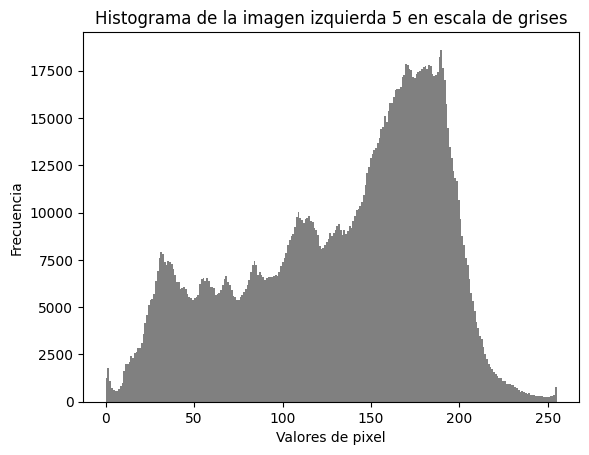

In [77]:
"""
cv2.calcHist Cálculo del histograma de una imagen con OpenCV

Args:
    imagen: Imagen a calcularle el histograma.
    canales: lista desde cero hasta numero de canales.
    mask: Si aplica.
    bins: En lista por canal rango de valores por pixel.
Returns:
    Cálculo del histograma.
"""
histograma = cv2.calcHist(imagen_GRAYSCALE, [0], None, [256], [0,255])

# También se puede obtener y mostrar el histograma directamente con Matplotlib
# Sólo la imagen se debe desdoblar (2D -> 1D) en el cálculo del histograma.
plt.figure()
#plt.plot(histograma) # Tambíen se puede graficar el histograma calculado con cv2.
plt.hist(imagen_GRAYSCALE.flatten(), bins=256, range=(0,255), color="gray")
plt.xlabel("Valores de pixel")
plt.ylabel("Frecuencia")
plt.title("Histograma de la imagen izquierda 5 en escala de grises")
plt.show()

In [79]:
def calcular_entropia(imagen):
    """Calcula la entropía de una imagen en escala de grises"""
    if len(imagen.shape) == 3:
        imagen = cv2.cvtColor(imagen, cv2.COLOR_BGR2GRAY)
    
    # Calcular histograma normalizado
    hist = cv2.calcHist([imagen], [0], None, [256], [0, 256])
    hist_norm = hist / hist.sum()
    
    # Eliminar ceros para evitar problemas con log
    hist_norm = hist_norm[hist_norm > 0]
    
    # Calcular entropía
    entropia = -np.sum(hist_norm * np.log2(hist_norm))
    
    return entropia 

In [80]:

imagen_GRAYSCALE_flat = imagen_GRAYSCALE.flatten()

media = np.mean(imagen_GRAYSCALE_flat)
mediana = np.median(imagen_GRAYSCALE_flat)
desviacion_std = np.std(imagen_GRAYSCALE_flat)
contraste = imagen_GRAYSCALE_flat.max() - imagen_GRAYSCALE_flat.min()
entropia = calcular_entropia(imagen_GRAYSCALE)

print(f"Media: {media}, Mediana: {mediana}, Desviación Estándar: {desviacion_std}, Contraste: {contraste}, Entropía: {entropia}")

Media: 132.86758645833334, Mediana: 147.0, Desviación Estándar: 55.07821874566797, Contraste: 255, Entropía: 7.623847961425781
